# 27 -- gamma_* comparison: sledgehamr vs surrogate, N_b > 3

One panel per ($\bar\lambda$, $\gamma_*$) for all many-bubble runs, plus the
integrated-power ratio. Surrogate = numerical wall radius (`--wall-radius`)
+ measured-wall, gamma-dependent patch-fraction damping
(`data/patch_fraction_calibration_measured.json`); dotted = same without the
damping. Simulation curves use the (A+B)/2-averaged sledgehamr output, as in
notebook 22.

Weights outputs are not tracked (hundreds of MB); Section 1 regenerates any
that are missing (N_b=3550 takes ~1 h on a laptop). Requires the built
`cpp/weights/weights` binary.

In [1]:
from pathlib import Path
import subprocess
import tempfile
import os

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams

import ptbuilder as pt
from ptbuilder.analysis import (
    load_scan, load_scan_manifest, load_weights, reconstruct_pair_spectrum,
    build_runtime_scan_interpolator, to_chw, apply_keffsq, write_weights_input,
)
from ptbuilder.sledgehamr import (
    load_output, get_gw_spectrum, get_spectrum_interpolated_at_time,
)
from ptbuilder.weight_scan_diagnostics import load_kinematics
from ptbuilder.ic import _cutoff_times

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

REPO_ROOT   = Path(pt.__file__).parent.parent
DATA_DIR    = REPO_ROOT / 'data'
SH_RUNS_DIR = REPO_ROOT / 'sledgehamr_runs'
PLOTS_DIR   = REPO_ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

RECON_KR_MIN, RECON_KR_MAX = 1., 100.   # every scan's guaranteed kR_* coverage
RECON_KR_MAX_IPR = 30.                  # integrated-power band upper edge


class AveragedOutput:
    """Wraps two sledgehamr Output objects with identical snapshot times,
    exposing the same interface (GetTimesOfGravitationalWaveSpectra,
    GetGravitationalWaveSpectrum) but returning the mean of their two raw
    'Spectrum' arrays at each snapshot -- a drop-in replacement usable
    anywhere a plain Output is."""
    def __init__(self, out_a, out_b):
        self._a, self._b = out_a, out_b

    def GetTimesOfGravitationalWaveSpectra(self):
        return self._a.GetTimesOfGravitationalWaveSpectra()

    def GetGravitationalWaveSpectrum(self, idx):
        da = self._a.GetGravitationalWaveSpectrum(idx)
        db = self._b.GetGravitationalWaveSpectrum(idx)
        assert abs(da['t'] - db['t']) < 1e-6, (da['t'], db['t'])
        return {'t': da['t'], 'k_sq': da['k_sq'],
               'spectrum': 0.5 * (da['spectrum'] + db['spectrum'])}


def load_averaged_output(path, secondary_subdir='gw_spec_u_times_k'):
    """Load a sledgehamr run's primary (gw_spectra) and a sibling secondary
    spectrum folder (e.g. gw_spec_u_times_k) as one AveragedOutput. The
    secondary folder is exposed to pySledgehamr's Output loader via a
    symlink named 'gw_spectra' in a temp dir, since Output hardcodes that
    subdirectory name."""
    path = Path(path)
    out_a = load_output(str(path))
    tmpdir = Path(tempfile.mkdtemp())
    os.symlink((path / secondary_subdir).resolve(), tmpdir / 'gw_spectra')
    out_b = load_output(str(tmpdir))
    return AveragedOutput(out_a, out_b)

import subprocess, shutil, time, warnings
from scipy.interpolate import interp1d
from scipy.spatial import Voronoi, cKDTree
from ptbuilder.analysis import reconstruct_pair_spectrum_series
from ptbuilder.patch_fraction import load_gamma_response, damped_weights

def late_time_band(pi, w, gam, weights_times, sh_out, interp_fn, times_bounds, gammas, k_out, Rstar, L, zero_pad, lb, t_max):
    Leff = L * zero_pad
    recon = np.zeros(len(k_out))
    for p in range(len(pi)):
        recon += reconstruct_pair_spectrum(float(gam[p]), w[p], weights_times, t_max,
                                           interp_fn, times_bounds, gammas)
    recon = to_chw(recon, Rstar, lb, L ** 3)
    kR_recon = k_out * Rstar
    valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
    kR_recon, recon = kR_recon[valid], recon[valid]

    sum_w = w.sum(axis=0)
    active = np.where(sum_w > 0.01)[0]
    t_coll_end = float(weights_times[active[-1]])
    times = np.array(sh_out.GetTimesOfGravitationalWaveSpectra())
    late_idx = np.where(times >= t_coll_end)[0]

    k_ref, spec_ref, _ = get_gw_spectrum(sh_out, int(late_idx[-1]), L, zero_pad)
    k_ref, spec_ref = k_ref[1:], spec_ref[1:]
    late_3d = []
    for idx in late_idx:
        k_late, y_late, _ = get_gw_spectrum(sh_out, int(idx), L, zero_pad)
        k_late, y_late = k_late[1:], y_late[1:]
        late_3d.append(np.interp(k_ref, k_late, y_late, left=np.nan, right=np.nan))
    late_3d = np.asarray(late_3d)
    late_median = to_chw(np.nanmedian(late_3d, axis=0), Rstar, lb, L ** 3)
    late_min    = to_chw(np.nanmin(late_3d, axis=0), Rstar, lb, L ** 3)
    late_max    = to_chw(np.nanmax(late_3d, axis=0), Rstar, lb, L ** 3)

    r_ref = k_ref * Leff / (2 * np.pi)
    n_modes = np.maximum(1., 4 * np.pi * r_ref ** 2)
    sigma_modes = late_median * np.sqrt(2. / n_modes)
    late_min = late_median - np.sqrt((late_median - late_min) ** 2 + sigma_modes ** 2)
    late_max = late_median + np.sqrt((late_max - late_median) ** 2 + sigma_modes ** 2)

    return dict(kR_recon=kR_recon, y_recon=recon, kR_sh=k_ref * Rstar,
               y_median=late_median, y_min=late_min, y_max=late_max,
               t_range=(times[late_idx[0]], times[late_idx[-1]]))


X_MAX = 150.
def visible_extent(*xy_pairs, x_min=None, x_max=X_MAX):
    ys, xmins = [], []
    for x, y in xy_pairs:
        mask = x <= x_max
        if x_min is not None:
            mask &= x >= x_min
        if mask.any():
            ys.append(y[mask])
            xmins.append(x[mask].min())
    ys = np.concatenate(ys)
    ys = ys[ys > 0]
    return min(xmins), ys.min(), ys.max()


def style_panel(ax, x_min, ymin, ymax, title):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min / 1.15, X_MAX)
    ax.set_ylim(ymin / 1.5, ymax * 1.5)
    ax.set_xlabel(r'$kR_*$', fontsize=12)
    ax.text(0.95, 0.96, title, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc='lower left')
    ax.tick_params(axis='both', labelsize=11, top=True, right=True, direction='in')

In [2]:
# One entry per run. lb: scan/calibration family; lb_ic: instanton of the
# initial state (sets the gamma_ij labels); new=True: weights input built here
# from the initial state (grid up to the box-filling time) and the damped
# weights extended one R_* past it; new=False: tracked weights input.
# NOTE: the N_b=512 input was built with lambda_bar=0.845 radii but its damping
# recovers pair separations with the 0.84 radii (lb_d below), ~3% off in d --
# kept as in the published figures.
RUNS = [
 dict(lb=.84, lb_ic="0.844777", ic="Cutting_lb0.845_N3550_L435.37", sh="Cutting_lb0.845_N3550_L435.37", new=True, gamma_panel=2, col="C0", ipr_col="C0"),
 dict(lb=.84, lb_ic="0.844777", ic="Cutting_lb0.845_N256_L181.21", sh="Cutting_lb0.845_N256_L181.21", new=True, gamma_panel=2, col="tab:orange", ipr_col="C8"),
 dict(lb=.84, lb_ic="0.844777", ic="Cutting_lb0.845_N323_L293.91", sh="Cutting_lb0.845_N323_L293.91", new=True, gamma_panel=3, col="C0", ipr_col="C1"),
 dict(lb=.84, lb_ic="0.84", lb_d="0.84", ic="Cutting_lb0.845_N64_g3.94", sh="Cutting_lb0.84_N64_g3.94_long", new=False, win="N64_lb084_correct", gamma_panel=4, col="C0", ipr_col="C2"),
 dict(lb=.84, lb_ic="0.845", lb_d="0.84", ic="Cutting_lb0.845_N512_g4.00", sh="Cutting_lb0.84_N512_g4.00", new=False, win="N512_lb084_g4_t146", gamma_panel=4, col="tab:brown", ipr_col="C3"),
 dict(lb=.84, lb_ic="0.844777", ic="Cutting_lb0.845_N15_L176.15", sh="Cutting_lb0.845_N15_L176.15", new=True, gamma_panel=5, col="C0", ipr_col="C4"),
 dict(lb=.069, lb_ic="0.069", ic="Cutting_lb0.069_N818_L58.07", sh="Cutting_lb0.069_N818_L58.07", new=True, gamma_panel=3, col="C0", ipr_col="C1"),
 dict(lb=.069, lb_ic="0.069", ic="Cutting_lb0.069_N64_g4.00_v4", sh="Cutting_lb0.069_N64_g4.00_leapfrog_2048_long_v2", new=False, win="N64_lb069_v4", gamma_panel=4, col="C0", ipr_col="C2"),
 dict(lb=.069, lb_ic="0.069", ic="Cutting_lb0.069_N34_L33.8", sh="Cutting_lb0.069_N34_L33.8", new=True, gamma_panel=5, col="C0", ipr_col="C4"),
 dict(lb=.069, lb_ic="0.069", ic="Cutting_lb0.069_N11_L27.88", sh="Cutting_lb0.069_N11_L27.88", new=True, gamma_panel=6, col="tab:purple", ipr_col="C6"),
 dict(lb=.069, lb_ic="0.069", ic="Cutting_lb0.069_N48_g6.00", sh="Cutting_lb0.069_N48_g6.00", new=False, win="N48_lb069_g6", gamma_panel=6, col="C0", ipr_col="C5"),
]
for r in RUNS:
    key = r["ic"] if r["new"] else r["win"]
    r["win_path"] = DATA_DIR / f"weights_in_{key}.h5"
    r["rnum_path"] = DATA_DIR / f"weights_out_{key}_rnum.h5"
    r["pfm_path"] = DATA_DIR / (f"weights_out_{key}_rnum_pfm_ext.h5" if r["new"] else f"weights_out_{key}_rnum_pfm.h5")
    with h5py.File(SH_RUNS_DIR / f"{r['ic']}.h5") as f:
        hdr = f["Header"][:]; r["N_b"] = len(f["xlocs"])
    r["L"], r["gamma_star"] = float(hdr[1]), float(hdr[3])
    r["R_star"] = (r["L"]**3 / r["N_b"]) ** (1 / 3)
    r["label"] = rf"$N_b={r['N_b']}$"

## 1. Weights (regenerated only if missing)

In [3]:
REGENERATE = False   # True: recompute every weights file, even if present
WEIGHTS_BIN = REPO_ROOT / "cpp/weights/weights"
CALIBRATION = DATA_DIR / "patch_fraction_calibration_measured.json"


def covering_radius(P, L):
    """Largest distance from any point of the periodic box to its nearest bubble centre."""
    m = 0.35 * L; imgs = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dz in (-1, 0, 1):
                Q = P + L * np.array([dx, dy, dz]); imgs.append(Q[np.all((Q > -m) & (Q < L + m), axis=1)])
    V = Voronoi(np.vstack(imgs)).vertices; V = V[np.all((V >= 0) & (V < L), axis=1)]
    return cKDTree(P, boxsize=L).query(V)[0].max()


def make_weights(r, out_dir=DATA_DIR):
    wall = DATA_DIR / f"wall_radius/lb{r['lb']}.h5"
    win, rnum, pfm = (Path(out_dir) / p.name for p in (r["win_path"], r["rnum_path"], r["pfm_path"]))
    if r["new"]:
        # grid up to 5% past the box-filling time (after which every weight is 0), steps R_*/450
        with h5py.File(SH_RUNS_DIR / f"{r['ic']}.h5") as f:
            P = np.column_stack([f["xlocs"][:], f["ylocs"][:], f["zlocs"][:]]) % r["L"]
        with h5py.File(wall) as tab:
            t_fill = np.interp(covering_radius(P, r["L"]), tab["R_mid"][:], tab["s"][:])
        t_end = 1.05 * t_fill; n = int(np.ceil((t_end - 1.) / (r["R_star"] / 450.))) + 1
        kin = load_kinematics(DATA_DIR / f"phi4_lambda_bar{r['lb_ic']}" / "instanton.h5")
        write_weights_input(path=win, positions=P, t=np.linspace(1., t_end, n), kinematics=kin,
                            L=r["L"], collision_radius="mid")
    subprocess.run([str(WEIGHTS_BIN), str(win if r["new"] else r["win_path"]), str(rnum),
                    "--wall-radius", str(wall)], check=True, capture_output=True)
    with h5py.File(win if r["new"] else r["win_path"]) as f:
        t = f["t"][:]
    w, pi, pj, g = load_weights(rnum, len(t))
    prof = pt.PhysicsModel(pt.Phi4Potential(float(r.get("lb_d", r["lb_ic"]))), pt.Config()).instanton
    kern = load_gamma_response(CALIBRATION, r["lb"], "fixed_annulus", 2, "zero")
    if r["new"]:
        # the damping tail outlives the raw weights: extend one R_* past the grid end
        weff, tg = damped_weights(w, t, g, prof, kern, t_end=t[-1] + r["R_star"],
                                  extension_spacing=r["R_star"] / 150.)
        with h5py.File(pfm, "w") as o, h5py.File(rnum) as src:
            for k, v in src.attrs.items(): o.attrs[k] = v
            o.attrs["n_pairs"] = len(g); o.attrs["n_t"] = len(tg)
            for k, v in dict(weights=weff.ravel(), pair_i=pi, pair_j=pj, gamma=g, t=tg).items():
                o.create_dataset(k, data=v)
    else:
        weff, _ = damped_weights(w, t, g, prof, kern)
        shutil.copy(rnum, pfm)
        with h5py.File(pfm, "r+") as o:
            o["weights"][...] = weff.ravel()
    with h5py.File(pfm, "r+") as o:
        o.attrs["patch_fraction"] = "measured-wall calibration, gamma-interpolated, fixed_annulus, alpha=2, tail=zero"


for r in RUNS:
    if REGENERATE or not (r["rnum_path"].exists() and r["pfm_path"].exists()):
        t0 = time.time(); make_weights(r); print(f"{r['ic']}: weights regenerated in {time.time() - t0:.0f} s")


def weights_grid(r, damped):
    """(weights, pair_i, pair_j, gamma, times) of a run's damped or undamped weights."""
    path = r["pfm_path"] if damped else r["rnum_path"]
    src = r["pfm_path"] if (damped and r["new"]) else r["win_path"]
    with h5py.File(src) as f:
        t = f["t"][:]
    return (*load_weights(path, len(t)), t)

## 2. Spectra, one panel per ($\bar\lambda$, $\gamma_*$)

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 57
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 57
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


Loaded scan runtime_scan_lb0.84_gs1-7_kR1-100_nw32: 43 rows, gamma_ij in [1.000, 17.500], T_MAX=145.617


lb=0.84 $N_b=3550$: gamma*=2.00  surrogate at t/R*=2.35  SH band t/R*=2.36-4.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 58
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 58
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.84 $N_b=256$: gamma*=2.00  surrogate at t/R*=2.24  SH band t/R*=1.91-4.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 87
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 87
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.84 $N_b=323$: gamma*=3.00  surrogate at t/R*=2.41  SH band t/R*=2.30-4.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


...

lb=0.069 $N_b=818$: gamma*=3.00  surrogate at t/R*=2.42  SH band t/R*=2.42-4.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 223
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 223
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.069 $N_b=64$: gamma*=4.00  surrogate at t/R*=2.40  SH band t/R*=2.11-8.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 140
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 140
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.069 $N_b=34$: gamma*=5.00  surrogate at t/R*=2.34  SH band t/R*=1.93-4.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 167
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 167
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.069 $N_b=11$: gamma*=6.00  surrogate at t/R*=2.22  SH band t/R*=1.95-4.00
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.069 $N_b=48$: gamma*=6.00  surrogate at t/R*=3.19  SH band t/R*=2.03-8.00


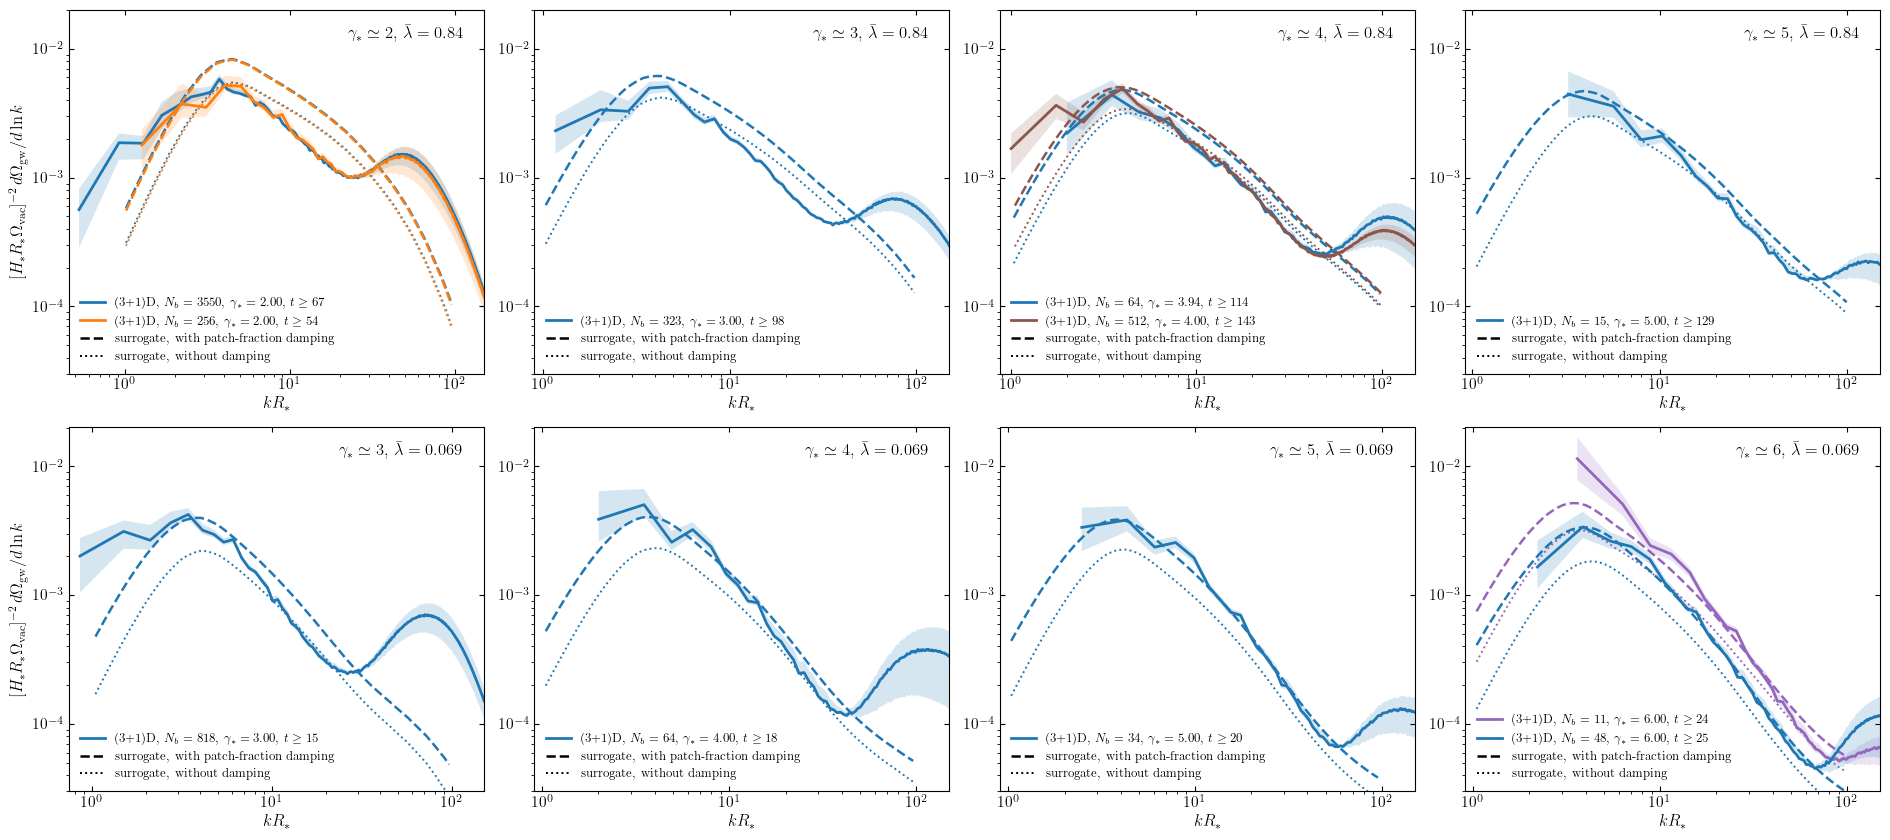

In [4]:
SCANS = {0.84: ("runtime_scan_lb0.84_gs1-7_kR1-100_nw32", load_scan),
         0.069: ("runtime_scan_lb0.069_gs1-11_kR1-100_nw32", load_scan_manifest)}
scan_cache = {}
def scan_for(lb):
    if lb not in scan_cache:
        d, loader = SCANS[lb]; sc = loader(DATA_DIR / d)
        k_out = np.geomspace(sc.rows[0].wlist[0], max(r.wlist[-1] for r in sc.rows), 128)
        f, g = build_runtime_scan_interpolator(sc, k_out)
        scan_cache[lb] = (f, g, k_out, np.array([min(r.times[0] for r in sc.rows), sc.t_max]))
    return scan_cache[lb]


def recon(w, t, gam, lb, T, R, L):
    f_i, g_s, k_out, tb = scan_for(lb)
    s = sum(reconstruct_pair_spectrum(float(g), w[p], t, T, f_i, tb, g_s) for p, g in enumerate(gam))
    y = to_chw(s, R, lb, L**3); kR = k_out * R; m = (kR >= RECON_KR_MIN) & (kR <= RECON_KR_MAX)
    return kR[m], y[m]


results = []
for r in RUNS:
    w, pi, pj, gam, t = weights_grid(r, damped=True)
    sh = load_averaged_output(SH_RUNS_DIR / r["sh"])
    T2 = min(float(t[-1]), float(np.max(sh.GetTimesOfGravitationalWaveSpectra())))
    f_i, g_s, k_out, tb = scan_for(r["lb"])
    res = late_time_band(pi, w, gam, t, sh, f_i, tb, g_s, k_out, r["R_star"], r["L"], 1., r["lb"], T2)
    wu, _, _, gu, tu = weights_grid(r, damped=False)
    res["kR_und"], res["y_und"] = recon(wu, tu, gu, r["lb"], T2, r["R_star"], r["L"])
    res.update(run=r, T2=T2)
    results.append(res)
    print(f"lb={r['lb']} {r['label']}: gamma*={r['gamma_star']:.2f}  surrogate at t/R*={T2 / r['R_star']:.2f}  "
          f"SH band t/R*={res['t_range'][0] / r['R_star']:.2f}-{res['t_range'][1] / r['R_star']:.2f}")

PANELS = {0.84: [2, 3, 4, 5], 0.069: [3, 4, 5, 6]}
fig, axes = plt.subplots(2, 4, figsize=(19, 8.5))
for row, lb in enumerate([0.84, 0.069]):
    for c, gp in enumerate(PANELS[lb]):
        ax = axes[row, c]; ext = []
        for res in [x for x in results if x["run"]["lb"] == lb and x["run"]["gamma_panel"] == gp]:
            r, col = res["run"], res["run"]["col"]
            ax.fill_between(res["kR_sh"], res["y_min"], res["y_max"], color=col, alpha=0.18, linewidth=0)
            ax.plot(res["kR_sh"], res["y_median"], color=col, lw=2,
                    label=rf"(3+1)D, {r['label']}, $\gamma_*={r['gamma_star']:.2f}$, $t\geq{res['t_range'][0]:.0f}$")
            ax.plot(res["kR_recon"], res["y_recon"], color=col, lw=1.8, ls="--")
            ax.plot(res["kR_und"], res["y_und"], color=col, lw=1.4, ls=":")
            ext.append(visible_extent((res["kR_sh"], res["y_min"]), (res["kR_sh"], res["y_max"]), (res["kR_recon"], res["y_recon"])))
        ax.plot([], [], color="k", lw=1.8, ls="--", label="surrogate, with patch-fraction damping")
        ax.plot([], [], color="k", lw=1.4, ls=":", label="surrogate, without damping")
        style_panel(ax, min(e[0] for e in ext), min(e[1] for e in ext), max(e[2] for e in ext),
                    rf"$\gamma_*\simeq{gp}$,  $\bar\lambda={lb}$")
        ax.set_ylim(3e-5, 2e-2)
ylabel = r"$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$"
axes[0, 0].set_ylabel(ylabel, fontsize=12); axes[1, 0].set_ylabel(ylabel, fontsize=12)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "surrogate_gamma_star_panels_rnum_patchfraction_measured.pdf", bbox_inches="tight")
plt.show()

## 3. Integrated power: sledgehamr / surrogate over time

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 57
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 57
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 57
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxe

lb=0.84 $N_b=3550$, $\gamma_*=2$: final ratio ((t-t_coll_end)/R*=1.65) = 0.68
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 58
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 58
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 58
Number of slices of truncation errors fou

lb=0.84 $N_b=256$, $\gamma_*=2$: final ratio ((t-t_coll_end)/R*=2.11) = 0.60
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 87
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 87
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 87
Number of slices of truncation errors foun

lb=0.84 $N_b=323$, $\gamma_*=3$: final ratio ((t-t_coll_end)/R*=1.75) = 0.77
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 227
Number of slices of truncation errors f

lb=0.84 $N_b=64$, $\gamma_*=3.94$: final ratio ((t-t_coll_end)/R*=6.01) = 0.81
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 116
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 116
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 116
Number of slices of truncation errors

...

lb=0.069 $N_b=64$, $\gamma_*=4$: final ratio ((t-t_coll_end)/R*=5.89) = 1.08
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 140
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 140
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 140
Number of slices of truncation errors f

lb=0.069 $N_b=34$, $\gamma_*=5$: final ratio ((t-t_coll_end)/R*=2.08) = 0.98
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 167
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 167
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 167
Number of slices of truncation errors f

lb=0.069 $N_b=11$, $\gamma_*=6$: final ratio ((t-t_coll_end)/R*=2.07) = 1.68
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 333
Number of slices of truncation errors f

Number of gravitational wave spectra found: 333
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


lb=0.069 $N_b=48$, $\gamma_*=6$: final ratio ((t-t_coll_end)/R*=5.98) = 0.97


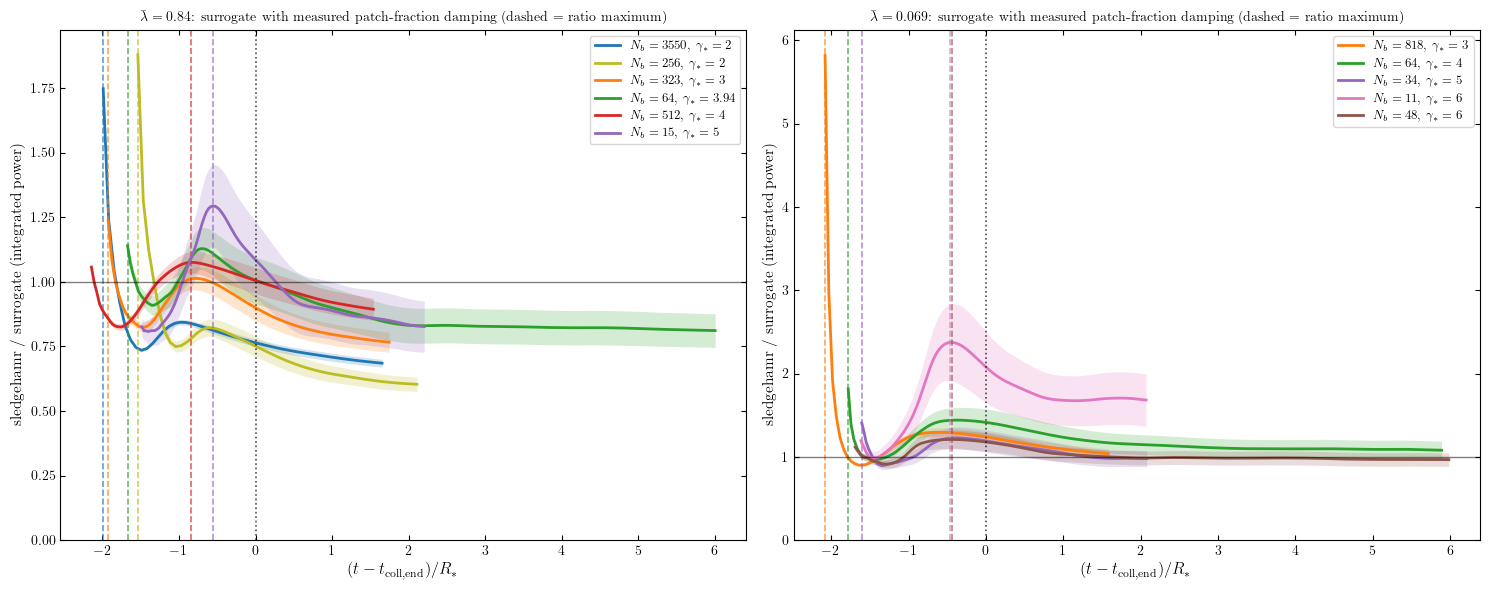

In [5]:
def integrate_band(y, kR, kR_min):
    m = (kR>=kR_min)&(kR<=RECON_KR_MAX_IPR)&(y>0)&np.isfinite(y)
    if m.sum() < 2:
        return np.nan
    order = np.argsort(kR[m])
    return np.trapz(y[m][order], np.log(kR[m][order]))

def integrate_band_with_err(y, yerr, kR, kR_min):
    """
    Same log-trapezoidal integral as integrate_band, plus its propagated
    uncertainty. yerr(k) is the per-k-bin shot-noise error already used
    elsewhere in this repo (yerr = y*sqrt(2/N_modes), N_modes ~ 4*pi*k^2 --
    the standard estimate for a Gaussian random field's power spectrum).
    Different k-shells of such a field are independent draws by construction
    (that's what justifies the per-bin sqrt(2/N_modes) formula in the first
    place), so the trapezoidal-weighted contributions can be summed in
    quadrature -- no new independence assumption beyond the one already
    built into the per-bin formula.
    """
    m = (kR>=kR_min)&(kR<=RECON_KR_MAX_IPR)&(y>0)&np.isfinite(y)
    if m.sum() < 2:
        return np.nan, np.nan
    order = np.argsort(kR[m])
    x, yv, ye = np.log(kR[m][order]), y[m][order], yerr[m][order]
    val = np.trapz(yv, x)
    w = np.zeros_like(x)
    w[1:-1] = 0.5 * (x[2:] - x[:-2])
    w[0] = 0.5 * (x[1] - x[0])
    w[-1] = 0.5 * (x[-1] - x[-2])
    err = np.sqrt(np.sum((w * ye) ** 2))
    return val, err

def measure_first_bin(sh_path, L, zero_pad):
    out = load_output(str(sh_path))
    idx = len(out.GetTimesOfGravitationalWaveSpectra()) // 2
    k, _, _ = get_gw_spectrum(out, idx, L, zero_pad)
    return float(k[1])

def peak_series(out, L, zero_pad, Rstar, lb, kR_min, times=None):
    """
    Returns (t, integrated_power, integrated_power_err) at each snapshot.
    Per-k error uses the same shot-noise convention as notebooks
    05/06/22 (yerr = y*sqrt(2/N_modes)), applied to the (A+B)/2-averaged
    spectrum and propagated through the k-integral (see
    integrate_band_with_err).
    """
    if times is None:
        times = np.array(out.GetTimesOfGravitationalWaveSpectra())
    tlist, plist, elist = [], [], []
    for idx, t in enumerate(times):
        raw = out.GetGravitationalWaveSpectrum(idx)
        k, spec, _ = get_gw_spectrum(out, idx, L, zero_pad)
        k, spec = k[1:], spec[1:]
        k_sq_raw = np.asarray(raw['k_sq'])[1:]
        if np.isnan(spec).any():
            continue
        y = to_chw(spec, Rstar, lb, L**3)
        kR = k*Rstar
        N_modes = np.maximum(1., 4. * np.pi * k_sq_raw)
        yerr = y * np.sqrt(2. / N_modes)
        val, err = integrate_band_with_err(y, yerr, kR, kR_min)
        if np.isfinite(val) and val > 0:
            tlist.append(t); plist.append(val); elist.append(err)
    return np.array(tlist), np.array(plist), np.array(elist)


fig, axes2 = plt.subplots(1, 2, figsize=(15, 6)); AX = {0.84: axes2[0], 0.069: axes2[1]}
x_max = 8.0
for r in RUNS:
    lb, ax, R, L = r["lb"], AX[r["lb"]], r["R_star"], r["L"]
    w, pi, pj, gam, t = weights_grid(r, damped=True)
    t_coll_end = float(t[np.where(w.sum(axis=0) > 0.01)[0][-1]])
    f_i, g_s, k_out, tb = scan_for(lb)
    kR_out = k_out * R
    kR_min = max(measure_first_bin(SH_RUNS_DIR / r["sh"], L, 1.), k_out[0]) * R
    sh_times = np.array(load_output(str(SH_RUNS_DIR / r["sh"])).GetTimesOfGravitationalWaveSpectra())
    ts, ps, es = peak_series(load_averaged_output(SH_RUNS_DIR / r["sh"]), L, 1., R, lb, kR_min, sh_times)
    m = ts / R <= x_max; ts, ps, es = ts[m], ps[m], es[m]
    t_grid = np.linspace(0.3, x_max * R, 400)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        comb = sum(reconstruct_pair_spectrum_series(float(g), w[c], t, t_grid, f_i, tb, g_s) for c, g in enumerate(gam))
    surr = np.array([integrate_band(to_chw(comb[i], R, lb, L**3), kR_out, kR_min) for i in range(len(t_grid))])
    ratio = ps / interp1d(t_grid, surr, bounds_error=False)(ts); err = ratio * es / ps
    ok = np.isfinite(ratio) & (ts > 0.3 * R); x = (ts[ok] - t_coll_end) / R
    lab = rf"{r['label']}, $\gamma_*={r['gamma_star']:.3g}$"
    ax.plot(x, ratio[ok], "-", color=r["ipr_col"], lw=2.0, label=lab)
    ax.fill_between(x, ratio[ok] - err[ok], ratio[ok] + err[ok], color=r["ipr_col"], alpha=0.2, linewidth=0)
    i_pk = np.nanargmax(ratio[ok]); ax.axvline(x[i_pk], color=r["ipr_col"], ls="--", lw=1.2, alpha=0.7)
    print(f"lb={lb} {lab}: final ratio ((t-t_coll_end)/R*={x[-1]:.2f}) = {ratio[ok][-1]:.2f}")
for lb, ax in AX.items():
    ax.axhline(1.0, color="k", lw=1.0, alpha=0.5); ax.axvline(0.0, color="k", ls=":", lw=1.2, alpha=0.7)
    ax.set_xlabel(r"$(t - t_{\rm coll,end})/R_*$", fontsize=12)
    ax.set_ylabel("sledgehamr / surrogate (integrated power)", fontsize=11)
    ax.set_title(rf"$\bar\lambda={lb}$: surrogate with measured patch-fraction damping (dashed = ratio maximum)", fontsize=10)
    ax.legend(fontsize=9, loc="upper right"); ax.tick_params(axis="both", direction="in", top=True, right=True); ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "integrated_power_ratio_gamma_star_rnum_patchfraction_measured.pdf")
plt.show()